# Import Libraries and Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import joblib

# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# 1. Data Understanding

In [2]:
print(df.head())
print(df.info())
print(df.describe())
print(df['Churn'].value_counts())
print(df.isnull().sum())

# Identify strange values (like " " in TotalCharges)
print("Rows with TotalCharges as ' ':", df[df['TotalCharges'] == ' '].shape[0])

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

# 2. Data Cleaning

In [3]:
# Convert TotalCharges to numeric, handle errors
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop rows with missing TotalCharges
df = df.dropna(subset=['TotalCharges'])

# Drop customerID
df = df.drop('customerID', axis=1)

# Encode Churn
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

# 3. Feature Engineering

In [4]:
# Create new columns
df['TenureGroup'] = pd.cut(df['tenure'], bins=[0,12,24,36,48,60,72], labels=['0-12', '13-24', '25-36', '37-48', '49-60', '61-72'])
df['AvgMonthlySpend'] = df['TotalCharges'] / df['tenure']

# Convert binary yes/no to 1/0
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = df[col].map({'Yes':1, 'No':0})

df['gender'] = df['gender'].map({'Male':1, 'Female':0})

# One-hot encoding will be done after EDA

# 4. EDA & Visualization

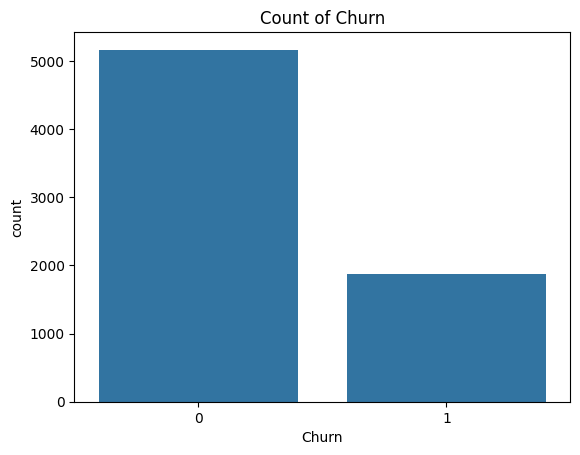

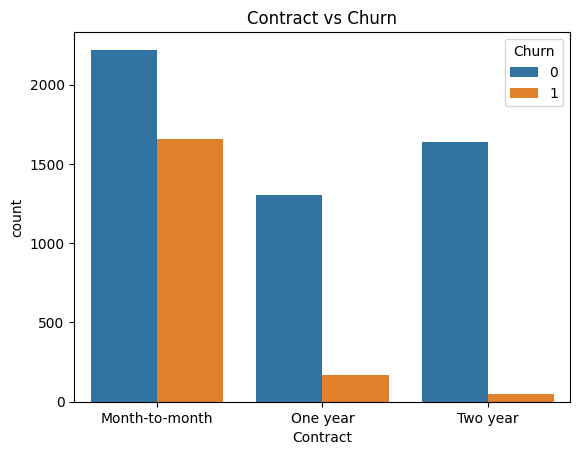

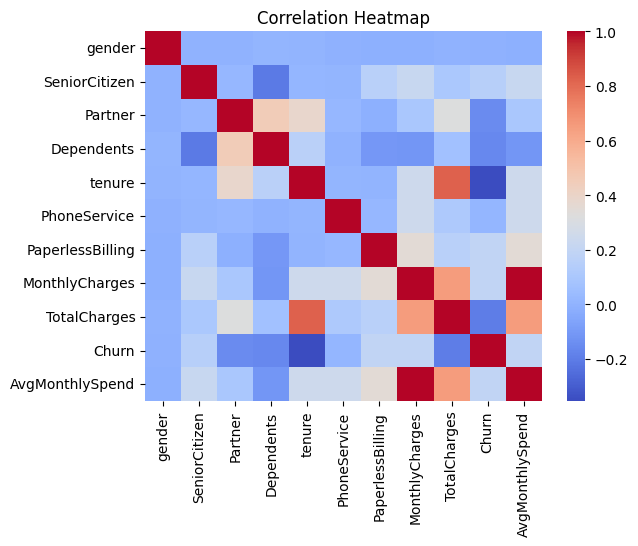

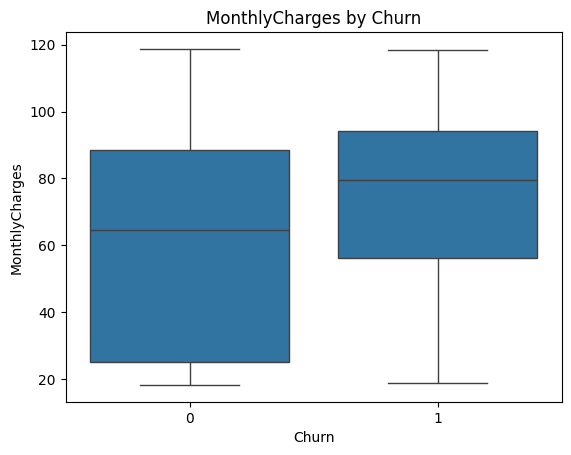

In [5]:
# Countplot for Churn
sns.countplot(data=df, x='Churn')
plt.title('Count of Churn')
plt.show()

# Barplot: Contract vs Churn
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Contract vs Churn')
plt.show()

# Heatmap of correlations
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Boxplot: MonthlyCharges by Churn
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('MonthlyCharges by Churn')
plt.show()